#K Nearest Neighbors

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import time
np.random.seed(42)

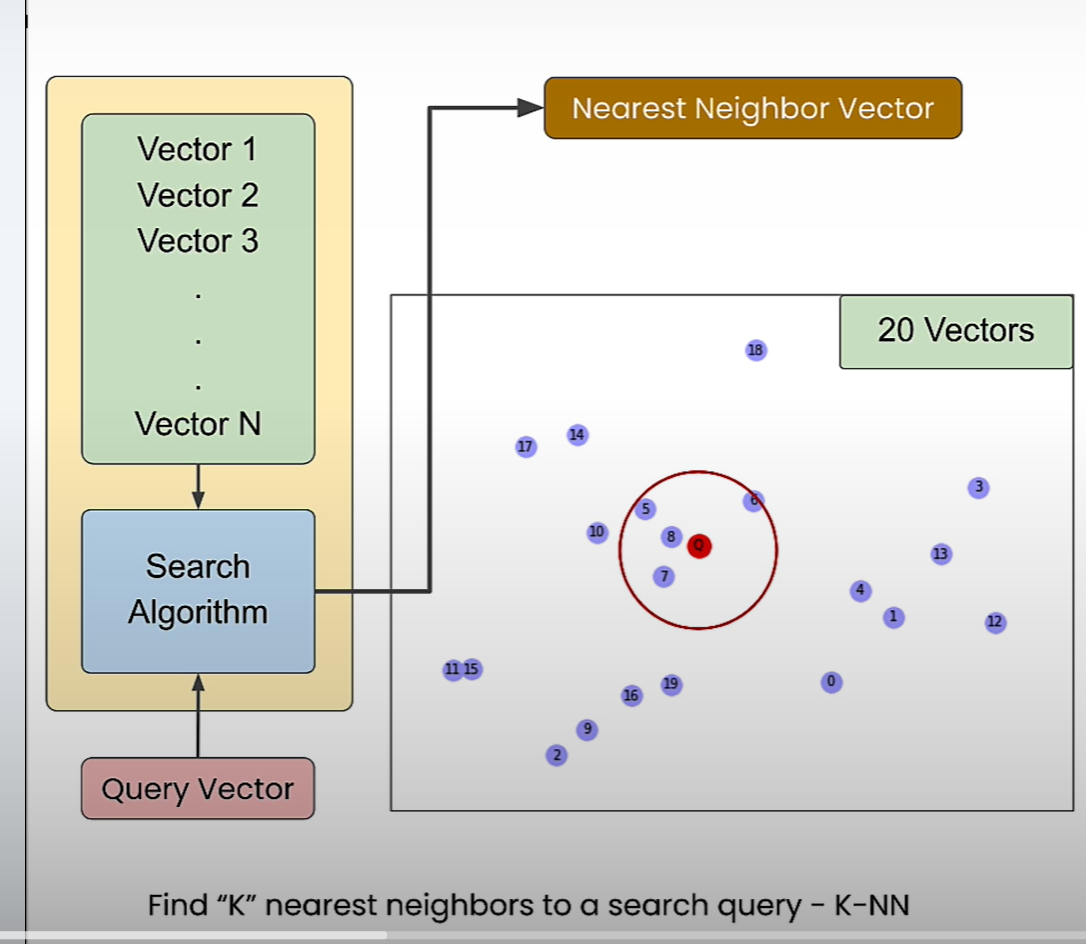

#Brute Force search algorithm

1. Measure the L2 distance between the Query and each vector

2. Sort all those distance  

3. Return the topk matches. These are the most sematically similar points


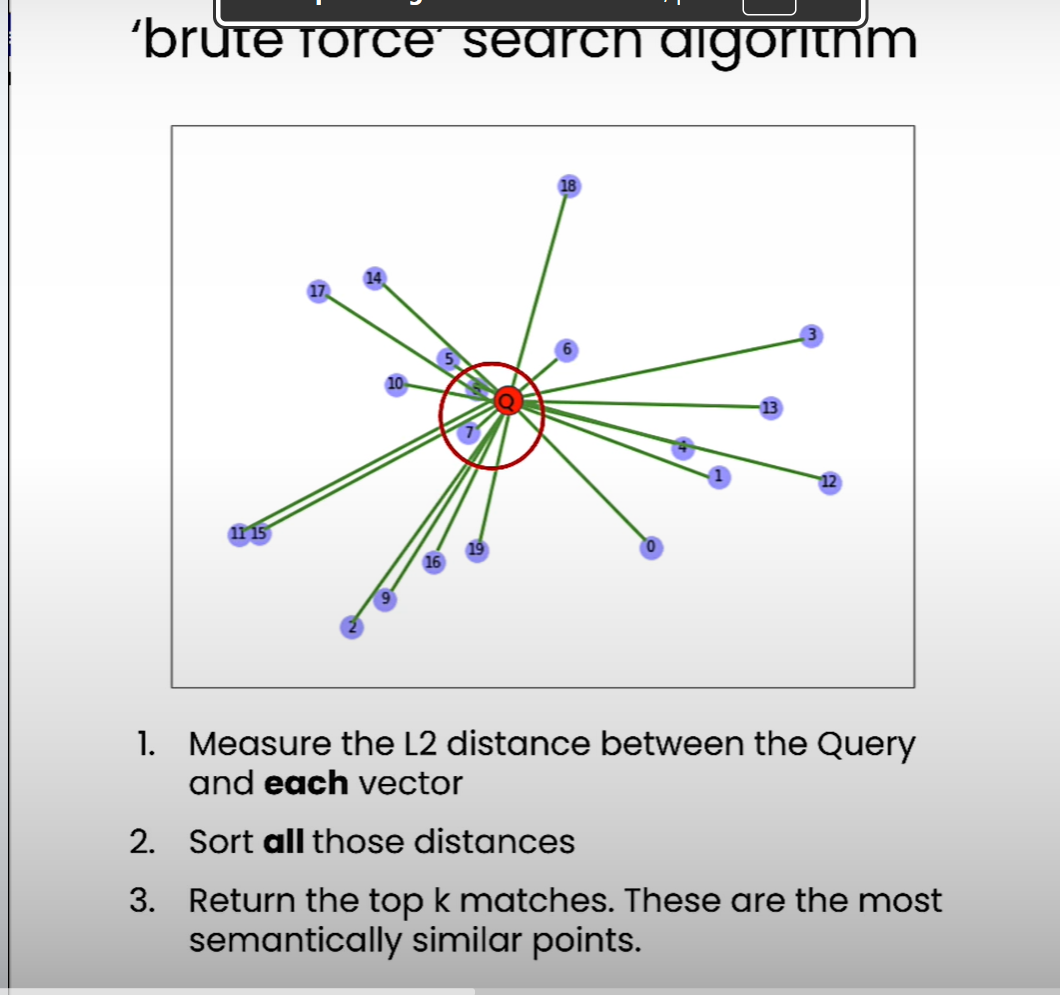

#Runtime complexity of KNN
. O(dN) run time complexity for search
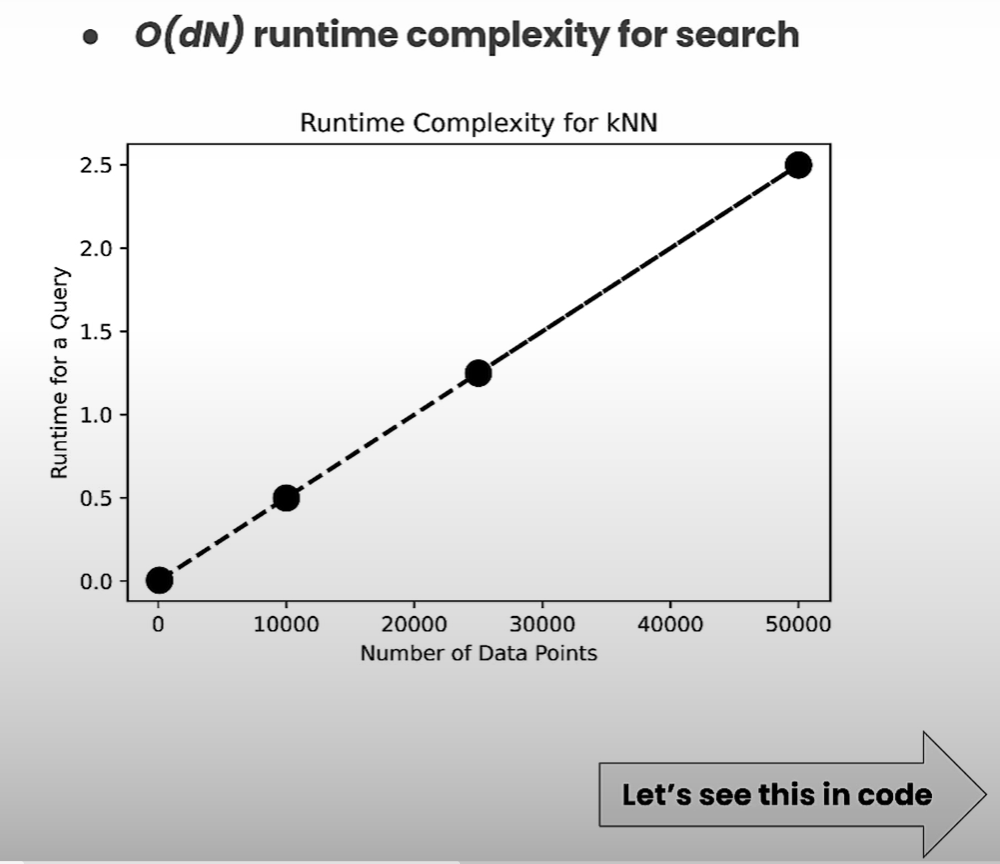


In [ ]:
#Generate 20 data points with 2 dimesions
X = np.random.rand(20,2)
X.shape

(20, 2)

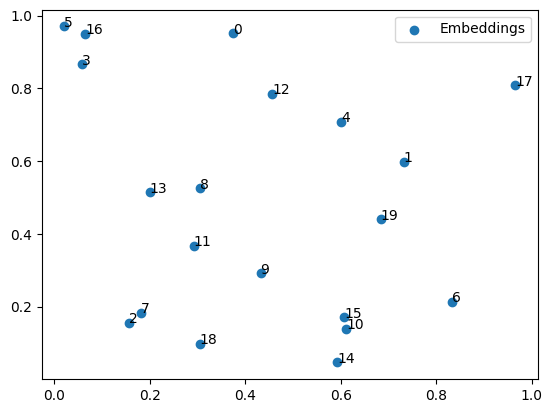

In [ ]:
#Display embeddings

# Display Embeddings
n = range(len(X))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], label='Embeddings')
ax.legend()

for i,txt in enumerate(n):
  ax.annotate(txt,(X[i,0],X[i,1]))

In [ ]:
k = 4
neigh = NearestNeighbors(n_neighbors=k,algorithm='brute',metric='euclidean')
neigh.fit(X)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=4)

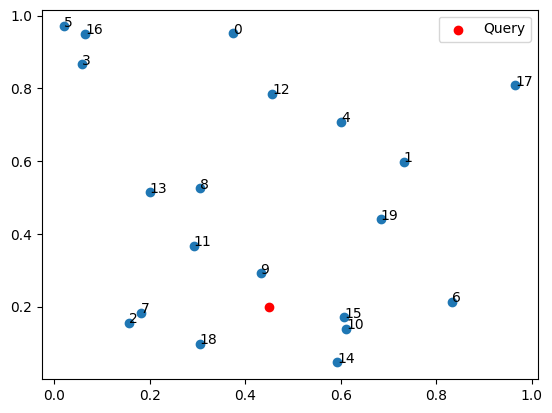

In [ ]:
# Display Query with data
n = range(len(X))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1])
ax.scatter(0.45,0.2, c='red',label='Query')
ax.legend()

for i, txt in enumerate(n):
    ax.annotate(txt, (X[i,0], X[i,1]))

In [ ]:
neighbours = neigh.kneighbors([[0.45,0.2]], k, return_distance=True)
print(neighbours)

(array([[0.09299859, 0.16027853, 0.1727928 , 0.17778682]]), array([[ 9, 15, 10, 18]]))


In [ ]:
t0 = time.time()
neighbours = neigh.kneighbors([[0.45,0.2]],k,return_distance=True)
t1 = time.time()
query_time = t1-t0
print(f"Runtime: {query_time: .4f} seconds")

Runtime:  0.0015 seconds


In [ ]:
def speed_test(count):
  data = np.random.rand(count,2)
  #prepare brute force index
  k = 4
  neigh = NearestNeighbors(n_neighbors=k,algorithm='brute', metric='euclidean')
  neigh.fit(data)
  #measure time for a brute force query
  t0 = time.time()
  neighbours = neigh.kneighbors([[0.45,0.2]],k,return_distance=True)
  t1 = time.time()
  total_time = t1-t0
  print(f'Runtime: {total_time:.4f}')
  return total_time



In [ ]:
time20k = speed_test(20_000)

Runtime: 0.0009


#Brute Force KNN implemented by hand on 768 dimesional embeddings

Generate random document vectors

        ↓
L2 normalize all document vectors

        ↓
Generate random query vector

        ↓

L2 normalize query

        ↓

Compute cosine similarity using dot product

        ↓

Sort similarities in descending order

        ↓
        
Pick top 5 most similar documents


In [ ]:
documents = 1000
dimensions = 768
embeddings = np.random.randn(documents, dimensions) # 1000 documents , 768 dimensional embeddings
# L2 normalize the rows, as is common
embeddings = embeddings / np.sqrt((embeddings**2).sum(1,keepdims=True))

query = np.random.randn(768) #query vector
query = query / np.sqrt((query**2).sum())


In [ ]:
# KNN
t0 = time.time()
# calculate dot product between the query and all data items
similarities = embeddings.dot(query)
# sort results
sorted_idx = np.argsort(-similarities)
t1 = time.time()
total = t1-t0
print(f"Runtime for dim={dimensions}, documents_n={documents}: {np.round(total,3)} seconds")
print("Top 5 results")
for k in sorted_idx[:5]:
  print(f"Point: {k}, Similarity: {similarities[k]}")


Runtime for dim=768, documents_n=1000: 0.011 seconds
Top 5 results
Point: 428, Similarity: 0.1279738933279838
Point: 238, Similarity: 0.11280608230463168
Point: 15, Similarity: 0.11192502018211119
Point: 206, Similarity: 0.10004904581657707
Point: 350, Similarity: 0.09906973839772476


In [ ]:
n_runs = [1_000, 10_000, 100_000, 500_000]

for n in n_runs:
    embeddings = np.random.randn(n, dimensions) #768-dimensional embeddings
    query = np.random.randn(768) # the query vector

    t0 = time.time()
    similarities = embeddings.dot(query)
    sorted_ix = np.argsort(-similarities)
    t1 = time.time()

    total = t1-t0
    print(f"Runtime for 1 query with dim={dimensions}, documents_n={n}: {np.round(total,3)} seconds")

Runtime for 1 query with dim=768, documents_n=1000: 0.001 seconds
Runtime for 1 query with dim=768, documents_n=10000: 0.009 seconds
Runtime for 1 query with dim=768, documents_n=100000: 0.051 seconds
Runtime for 1 query with dim=768, documents_n=500000: 0.28 seconds


In [ ]:
print (f"To run 1,000 queries: {total * 1_000/60 : .2f} minutes")

To run 1,000 queries:  4.67 minutes
